In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tusharpotdar/diabetes-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes-data' dataset.
Path to dataset files: /kaggle/input/diabetes-data


In [21]:
import os

# List contents of the directory to inspect its structure
print(f"Contents of {path}:\n{os.listdir(path)}")

Contents of /kaggle/input/diabetes-data:
['diabetes_data.csv']


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [23]:
df = pd.read_csv(os.path.join(path, "diabetes_data.csv"))

In [24]:
df.head(5)

,Unnamed: 0,Fasting_Blood_Glucose,Postprandial_Blood_Glucose,HbA1c,Random_Blood_Glucose,BMI,Waist_Circumference,Triglyceride_Levels,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,...,Gestational_Diabetes,PCOS,Hypertension,Physical_Activity,Smoking,Alcohol_Consumption,Obesity,Diet,Sleep_Apnea,Diabetes_Status
0,0,118.690215,111.472598,5.570234,224.721689,29.299897,37.872710,212.064239,93.491951,100.418755,...,Yes,No,Yes,Yes,No,Yes,No,No,No,Positive
1,1,193.592860,172.123161,5.481873,253.236721,35.135808,39.468713,93.096591,106.809528,98.109810,...,Yes,No,No,No,Yes,No,No,Yes,No,Negative
2,2,165.159212,228.400792,9.437527,127.607617,34.004023,47.090948,268.098641,164.812122,56.702794,...,No,No,No,Yes,Yes,No,Yes,No,No,Positive
3,3,147.825603,204.478231,5.497277,213.721043,18.847498,36.800088,203.279060,159.009152,114.580068,...,Yes,Yes,Yes,No,No,Yes,No,No,Yes,Positive
4,4,90.282423,217.115395,5.631698,201.501576,18.731237,47.392994,89.300971,121.557842,89.793054,...,Yes,Yes,No,Yes,No,Yes,No,Yes,Yes,Positive


In [25]:
df.shape

(3000, 36)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  3000 non-null   int64  
 1   Fasting_Blood_Glucose       3000 non-null   float64
 2   Postprandial_Blood_Glucose  3000 non-null   float64
 3   HbA1c                       3000 non-null   float64
 4   Random_Blood_Glucose        3000 non-null   float64
 5   BMI                         3000 non-null   float64
 6   Waist_Circumference         3000 non-null   float64
 7   Triglyceride_Levels         3000 non-null   float64
 8   Blood_Pressure_Systolic     3000 non-null   float64
 9   Blood_Pressure_Diastolic    3000 non-null   float64
 10  LDL_Cholesterol             3000 non-null   float64
 11  HDL_Cholesterol             3000 non-null   float64
 12  CRP_Levels                  3000 non-null   float64
 13  Insulin_Levels              3000 

In [27]:
columns_to_keep = [
    "HbA1c",
    "Fasting_Blood_Glucose",
    "Postprandial_Blood_Glucose",
    "Random_Blood_Glucose",
    "BMI"
]

In [28]:
X = df[columns_to_keep]
Y = df["Diabetes_Status"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, Y,test_size=0.2,random_state=42)

In [30]:
model = RandomForestClassifier(n_estimators=300, max_depth= 3,min_samples_leaf=2 , min_samples_split=5 ,random_state=42)


In [31]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [32]:
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [33]:
model.fit(X_train, y_train_encoded)

RandomForestClassifier(max_depth=3, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [34]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test_encoded, y_pred)

print("Accuracy:", accuracy)
print("Accuracy %:", accuracy * 100)

Accuracy: 0.8416666666666667
Accuracy %: 84.16666666666667


In [35]:
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.76      0.81       271
           1       0.82      0.91      0.86       329

    accuracy                           0.84       600
   macro avg       0.85      0.83      0.84       600
weighted avg       0.84      0.84      0.84       600



In [36]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

print(importance.sort_values(ascending=False))

Fasting_Blood_Glucose         0.382596
Postprandial_Blood_Glucose    0.259313
HbA1c                         0.242866
Random_Blood_Glucose          0.108475
BMI                           0.006750
dtype: float64


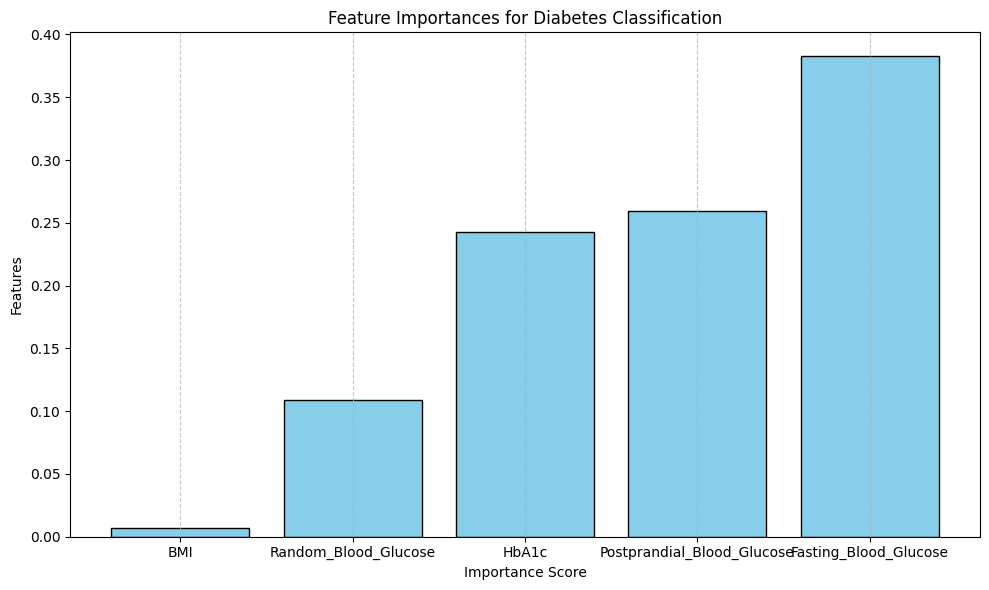

In [37]:
import matplotlib.pyplot as plt

sorted_importance = importance.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
plt.bar(sorted_importance.index, sorted_importance.values, color='skyblue', edgecolor='black')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importances for Diabetes Classification')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

In [38]:
import pandas as pd
import numpy as np

def predict_from_user_input():
    print("\n===== Diabetes Prediction =====")

    # Take input one by one
    hba1c = float(input("Enter HbA1c: "))
    fasting_bg = float(input("Enter Fasting Blood Glucose: "))
    postprandial_bg = float(input("Enter Postprandial Blood Glucose: "))
    random_bg = float(input("Enter Random Blood Glucose: "))
    bmi = float(input("Enter BMI: "))

    # Create input dictionary
    user_dict = {
        'HbA1c': hba1c,
        'Fasting_Blood_Glucose': fasting_bg,
        'Postprandial_Blood_Glucose': postprandial_bg,
        'Random_Blood_Glucose': random_bg,
        'BMI': bmi
    }

    # Create DataFrame with the same columns used during training
    input_df = pd.DataFrame([user_dict])[columns_to_keep]

    # Prediction
    prediction_encoded = model.predict(input_df)[0]

    # Probability
    probabilities = model.predict_proba(input_df)[0]

    # Convert encoded prediction back to original label
    predicted_class = le.inverse_transform([prediction_encoded])[0]

    # Get confidence
    confidence = probabilities[prediction_encoded] * 100

    # Display result
    print("\n========== RESULT ==========")
    print(f"Predicted Status : {predicted_class}")
    print(f"Confidence       : {confidence:.2f}%")

    print("\nProbabilities:")
    for class_idx, prob in enumerate(probabilities):
        class_name = le.inverse_transform([class_idx])[0]
        print(f"{class_name}: {prob * 100:.2f}%")

    print("============================")


# Run the prediction
predict_from_user_input()


===== Diabetes Prediction =====


KeyboardInterrupt: Interrupted by user

In [39]:
import joblib

# Save the model and the label encoder
joblib.dump(model, 'diabetes_model.joblib')
joblib.dump(le, 'label_encoder.joblib')

print("Model saved as 'diabetes_model.joblib'")
print("Label Encoder saved as 'label_encoder.joblib'")

Model saved as 'diabetes_model.joblib'
Label Encoder saved as 'label_encoder.joblib'
